In [1]:
import numpy as np
import re
import pandas as pd

In [2]:
df=pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [3]:
# pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)
# pd.set_option('display.max_colwidth',None)

In [4]:
df.head(1)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,godrej air,85,2.5,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,"pooja room,study room,others",16.0,North-East,Mar 2024,"['Sapphire 83 Mall', 'Sector 86 Road', 'Dwarka...","['4 Wardrobe', '1 Water Purifier', '4 Fan', '1...","['Security / Fire Alarm', 'Intercom Facility',..."


## 1. areaWithType

In [5]:
df[['area','areaWithType']].sample(5)

,area,areaWithType
734,1473.0,Super Built up area 1480(137.5 sq.m.)
3280,3660.0,Built Up area: 340
1710,1766.0,Super Built up area 2450(227.61 sq.m.)Carpet a...
2040,884.0,Carpet area: 900 (83.61 sq.m.)
2241,1747.0,Super Built up area 1747(162.3 sq.m.)


In [6]:
# this function extracts super built up area
def get_super_built_up_area(text):
    match=re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [7]:
#this function extracts the built up area or carpet area 
def get_area(text, area_type):
    match=re.search(area_type+r'\s*:\s*(\d+\.?\d+)',text)
    if match:
        return float(match.group(1))
    return None

In [8]:
#this function chcks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text,area_value):
    if area_value is None:
        return None
    match=re.search(r'{}\((\d+\.?\d*) sq.m.\)'.format(area_value),text)
    if match:
        sq_m_value=float(match.group(1))
        return sq_m_value*10.7639
    return area_value

In [9]:
#extract super built up area and convert to sqft if needed
df['super_built_up_area']=df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['super_built_up_area']),axis=1)
#extract built up area and convert to sqft if needed
df['built_up_area']=df['areaWithType'].apply(lambda x:get_area(x,'Built Up area'))
df['built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['built_up_area']),axis=1)
#extract carpet area and convert to sqft if needed
df['carpet_area']=df['areaWithType'].apply(lambda x:get_area(x,'Carpet area'))
df['carpet_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['carpet_area']),axis=1)

In [10]:
df.sample(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
3747,flat,ss the leaf,85,1.12,6453.0,1736.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,2,3,others,10.0,East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",1741.0,1485.0,1335.00
2461,flat,vatika gurgaon,83,1.25,6313.0,1980.0,Super Built up area 1980(183.95 sq.m.)Built Up...,3,3,2,servant room,12.0,North,5 to 10 Year Old,"['Huda Metro Station (Gurugram)', 'Sapphire 83...",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1980.0,1700.0,1400.00
1778,flat,emaar gurgaon greens,102,1.35,8181.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,servant room,9.0,North-East,1 to 5 Year Old,"['JMS Marine Square Mall', 'Dwarka Expressway'...","['3 Fan', '4 Light', '4 AC', '1 Modular Kitche...","['Intercom Facility', 'Lift(s)', 'Maintenance ...",1650.0,NaN,1022.58
3634,flat,indiabulls centrum park,103,1.20,8432.0,1423.0,Super Built up area 1423(132.2 sq.m.),2,2,3,not available,3.0,North-East,5 to 10 Year Old,"['Gurgaon Dreamz Mall', 'HUDA Market, Sector 1...",[],"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'M...",1423.0,NaN,NaN
2619,flat,smart world gems,89,0.90,8145.0,1105.0,Built Up area: 1105 (102.66 sq.m.),2,2,2,not available,1.0,NaN,undefined,"['Sant Soordas Sihi Metro Station', 'Airia Mal...",NaN,NaN,NaN,1105.0,NaN


In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,others,10.0,South-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F...",1741.0,1550.00,1350.00
5,flat,ss the leaf,85,1.09,6661.0,1636.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,not available,5.0,North-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",1640.0,1475.00,1350.00
10,flat,emaar mgf emerald floors premier,65,2.25,13636.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,"study room,servant room",3.0,South-West,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...",1650.0,1600.00,1350.00
17,flat,parsvnath exotica,53,5.00,17271.0,2895.0,Super Built up area 2895(268.95 sq.m.)Built Up...,3,4,3+,"pooja room,servant room,others",8.0,North-East,1 to 5 Year Old,"['Sector 53-54 Metro Station', 'Sahara Mall', ...","['6 Wardrobe', '1 Water Purifier', '3 Chimney'...","['Feng Shui / Vaastu Compliant', 'Security / F...",2895.0,2500.00,2200.00
39,flat,aipl zen residences,70,1.82,10996.0,1655.0,Super Built up area 1655(153.75 sq.m.)Built Up...,3,3,3,not available,12.0,South,1 to 5 Year Old,"['Airia Mall', 'National Highway 8', 'Southern...",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",1655.0,1600.00,1550.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3934,flat,emaar mgf the palm drive,66,1.51,15130.0,998.0,Super Built up area 1200(111.48 sq.m.)Built Up...,2,2,2,pooja room,5.0,North,1 to 5 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...","['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Intercom Facility', 'Lift(s)', 'High Ceiling...",1200.0,1188.00,998.00
3941,flat,experion the heartsong,108,1.60,7988.0,2003.0,Super Built up area 2003(186.08 sq.m.)Built Up...,3,4,3+,servant room,3.0,South,1 to 5 Year Old,"['Galleria 108 Mall', 'Dwarka Expressway', 'Ce...","['1 Wardrobe', '3 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Lift(s)', 'Maintena...",2003.0,1500.29,1140.98
3942,flat,sare homes,92,0.95,4250.0,2235.0,Super Built up area 2000(185.81 sq.m.)Built Up...,4,3,2,not available,16.0,East,0 to 1 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...","['5 Fan', '1 Exhaust Fan', '9 Light', '1 Curta...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",2000.0,1983.00,1900.00
3943,flat,ss the leaf,85,1.87,7780.0,2404.0,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,not available,7.0,North-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...",2408.0,2225.00,2175.00


In [12]:
df[df['areaWithType'].str.contains('Plot')].shape

(760, 20)

In [13]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_crore           20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1170
agePossession             1
nearbyLocations         201
furnishDetails         1029
features                703
super_built_up_area    2018
built_up_area          2719
carpet_area            1949
dtype: int64

In [14]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [15]:
all_nan_df.shape

(608, 7)

In [16]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price_in_crore','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [17]:
all_nan_df.head(100)

,price_in_crore,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.07,house,277.0,Plot area 33(27.59 sq.m.),NaN,NaN,NaN
7,15.00,house,4500.0,Plot area 500(418.06 sq.m.),NaN,NaN,NaN
11,2.75,house,1080.0,Plot area 120(100.34 sq.m.),NaN,NaN,NaN
13,0.27,house,225.0,Plot area 225(20.9 sq.m.),NaN,NaN,NaN
22,5.00,house,2250.0,Plot area 250(209.03 sq.m.),NaN,NaN,NaN
...,...,...,...,...,...,...,...
586,25.00,house,8036.0,Plot area 1000(836.13 sq.m.),NaN,NaN,NaN
590,4.00,house,981.0,Plot area 109(91.14 sq.m.),NaN,NaN,NaN
595,0.60,house,558.0,Plot area 62(51.84 sq.m.),NaN,NaN,NaN
596,6.25,house,5400.0,Plot area 600(501.68 sq.m.),NaN,NaN,NaN


In [18]:
#function to extract plot area from areawithtype column
def extract_plot_area(area_with_type):
    match=re.search(r'Plot area (\d+\.?\d*)',area_with_type)
    return float(match.group(1)) if match else None

In [19]:
all_nan_df['built_up_area']=all_nan_df['areaWithType'].apply(extract_plot_area)

In [20]:
all_nan_df.head(5)

,price_in_crore,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,0.07,house,277.0,Plot area 33(27.59 sq.m.),NaN,33.0,NaN
7,15.00,house,4500.0,Plot area 500(418.06 sq.m.),NaN,500.0,NaN
11,2.75,house,1080.0,Plot area 120(100.34 sq.m.),NaN,120.0,NaN
13,0.27,house,225.0,Plot area 225(20.9 sq.m.),NaN,225.0,NaN
22,5.00,house,2250.0,Plot area 250(209.03 sq.m.),NaN,250.0,NaN


In [21]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area'])==9.0:
            return row['built_up_area']*9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area']*10.7
        else:
            return row['built_up_area']

In [22]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_scale,axis=1)

In [23]:
#update the original dataframe
df.update(all_nan_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_crore           20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1170
agePossession             1
nearbyLocations         201
furnishDetails         1029
features                703
super_built_up_area    2018
built_up_area          2111
carpet_area            1949
dtype: int64

## 2.Additional Romm

In [25]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1686
servant room                                      709
study room                                        251
others                                            235
pooja room                                        170
                                                 ... 
pooja room,store room,servant room                  1
study room,others,servant room                      1
store room,servant room,study room,pooja room       1
store room,study room                               1
servant room,study room,store room,pooja room       1
Name: count, Length: 66, dtype: int64

In [26]:
#additional room
#list of new columns
new_cols=['study room','servant room','store room','pooja ghar','others']
#populate the new columns based on the 'additional room'
for col in new_cols:
    df[col]=df['additionalRoom'].str.contains(col).astype(int)

In [27]:
df.head(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,"['4 Wardrobe', '1 Water Purifier', '4 Fan', '1...","['Security / Fire Alarm', 'Intercom Facility',...",NaN,NaN,18122.0,1,0,0,0,1
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,...,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F...",1741.0,1550.0,1350.0,0,0,0,0,1
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,...,[],NaN,NaN,33.0,NaN,0,0,0,0,0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,...,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Security / Fire Alarm', 'Lift(s)', 'Maintena...",NaN,NaN,2267.0,0,1,0,0,0
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,...,[],"['Feng Shui / Vaastu Compliant', 'Security / F...",2727.0,NaN,NaN,0,1,0,0,1


## 3.age possession

In [28]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1703
5 to 10 Year Old       607
0 to 1 Year Old        550
undefined              356
10+ Year Old           351
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Aug 2023                 7
Dec 2025                 7
Nov 2023                 5
Aug 2024                 5
Jan 2025                 4
Jul 2024                 4
Oct 2023                 4
By 2025                  4
Sep 2023                 4
Feb 2024                 3
May 2024                 3
Nov 2024                 3
Jan 2026                 2
Aug 2025                 2
Jul 2025                 2
By 2027                  2
Jul 2027                 2
Sep 2025                 2
Oct 2025                 2
Apr 2026                 2
Jun 2027      

In [29]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [30]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [31]:
df['agePossession'].value_counts()

agePossession
Relatively New        1703
New Property           646
Moderately Old         607
Undefined              357
Old Property           351
Under Construction     287
Name: count, dtype: int64

In [32]:
df['agePossession'].sample(5)

3460        Relatively New
651         Moderately Old
2707        Relatively New
3745          Old Property
1962    Under Construction
Name: agePossession, dtype: object

In [33]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,"['4 Wardrobe', '1 Water Purifier', '4 Fan', '1...","['Security / Fire Alarm', 'Intercom Facility',...",NaN,NaN,18122.0,1,0,0,0,1
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,...,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F...",1741.0,1550.0,1350.0,0,0,0,0,1
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,...,[],NaN,NaN,33.0,NaN,0,0,0,0,0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,...,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Security / Fire Alarm', 'Lift(s)', 'Maintena...",NaN,NaN,2267.0,0,1,0,0,0
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,...,[],"['Feng Shui / Vaastu Compliant', 'Security / F...",2727.0,NaN,NaN,0,1,0,0,1


## 4.furnish details


In [34]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1689,"['1 Fan', '1 Geyser', '1 Light', '1 Chimney', ...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
407,"['3 Wardrobe', '6 Fan', '3 Geyser', '10 Light'...","['Centrally Air Conditioned', 'Water purifier'..."
807,"['3 Fan', '1 Exhaust Fan', '3 Geyser', '3 Ligh...","['Water purifier', 'Security / Fire Alarm', 'P..."
1313,[],"['Park', 'Club house / Community Center', 'Wat..."
2397,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F..."


In [35]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\palas\AppData\Local\Temp\ipykernel_2156\2118040236.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [36]:
furnishings_df.shape

(3951, 19)

In [37]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\palas\AppData\Local\Temp\ipykernel_2156\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [38]:
furnishings_df.sample(5)

,Sofa,Bed,AC,Washing Machine,Water Purifier,Wardrobe,Modular Kitchen,Curtains,Dining Table,Chimney,Light,TV,Geyser,Exhaust Fan,Fridge,Stove,Fan,Microwave
890,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2696,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2936,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3586,0,0,0,0,0,0,0,0,1,0,3,0,0,1,0,0,3,0
1861,0,0,0,0,0,4,1,1,0,0,9,0,2,1,0,0,10,0


In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [41]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

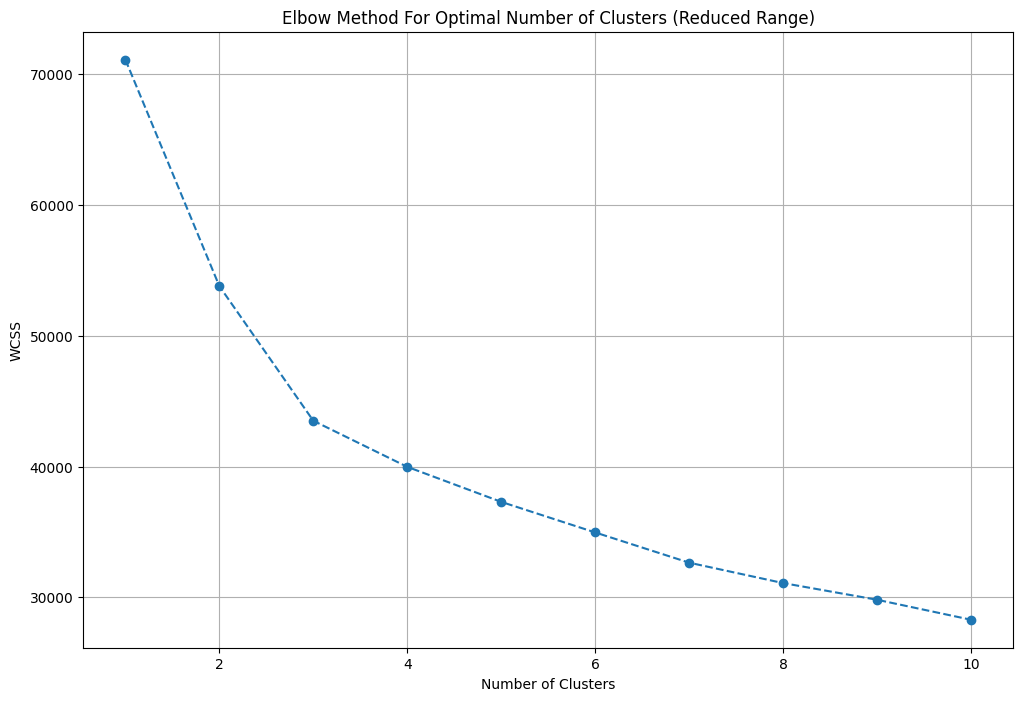

In [42]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [43]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [44]:
df = df.iloc[:,:-18]

In [45]:
df['furnishing_type'] = cluster_assignments

In [46]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
3445,"['13 Fan', '17 Light', '1 Modular Kitchen', 'N...",0
2887,[],1
1516,"['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '6 Li...",0
815,"['1 Water Purifier', '4 Fan', '1 Exhaust Fan',...",2
2467,NaN,1


## 5.features

In [47]:
df[['society','features']].sample(5)

,society,features
1303,ansal sushant residency,"['Feng Shui / Vaastu Compliant', 'Private Gard..."
2105,experion the heartsong,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
810,vatika gurgaon,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
2046,dlf new town heights,"['Centrally Air Conditioned', 'Water purifier'..."
3782,dlf new town heights,"['Water purifier', 'Security / Fire Alarm', 'P..."


In [48]:
df['features'].isnull().sum()

np.int64(703)

In [49]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [50]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [51]:
temp_df = df[df['features'].isnull()]

In [52]:
temp_df.shape

(703, 26)

In [53]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [54]:
df.loc[temp_df.index,'features'] = x.values

In [55]:
df['features'].isnull().sum()

np.int64(546)

In [56]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [57]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [58]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2873,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,1,0,0,0
1266,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,1,1,0,0
169,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2766,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
753,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
features_binary_df.shape

(3951, 130)

In [60]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

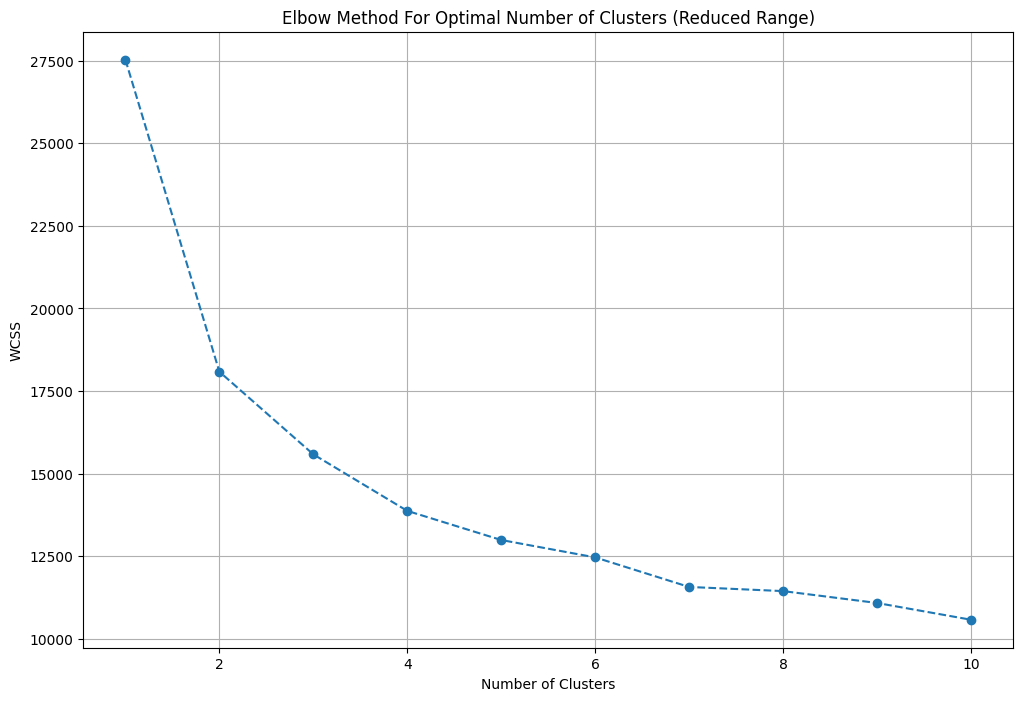

In [61]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [62]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [63]:
df['luxury_score'] = luxury_score

In [64]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,features_list,luxury_score
0,flat,godrej air,85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,18122.0,1,0,0,0,1,0,"[Security / Fire Alarm, Intercom Facility, Lif...",44
1,flat,ss the leaf,85,1.17,6720.0,1741.0,Super Built up area 1741(161.74 sq.m.)Built Up...,2,3,3,...,1550.0,1350.0,0,0,0,0,1,1,"[Feng Shui / Vaastu Compliant, Security / Fire...",49
2,house,independent,48,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,...,33.0,NaN,0,0,0,0,0,1,[],0
3,flat,brisk lumbini terrace homes,109,1.50,6616.0,2267.0,Carpet area: 2267 (210.61 sq.m.),3,3,1,...,NaN,2267.0,0,1,0,0,0,1,"[Security / Fire Alarm, Lift(s), Maintenance S...",37
4,flat,dlf new town heights,90,2.00,7334.0,2727.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,...,NaN,NaN,0,1,0,0,1,1,"[Feng Shui / Vaastu Compliant, Security / Fire...",49


In [65]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [66]:
df.sample(5)

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
1799,flat,m3m woodshire,107,1.32,6330.0,2085.0,Super Built up area 1943(180.51 sq.m.),3,3,3,...,1943.0,NaN,NaN,0,0,0,0,0,1,117
2184,flat,signature global solera,107,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,...,NaN,NaN,489.0,0,0,0,0,0,1,45
1858,flat,smart world orchard,61,2.20,14202.0,1549.0,Carpet area: 1549 (143.91 sq.m.),3,3,2,...,NaN,NaN,1549.0,0,0,0,0,0,1,152
2380,flat,m3m woodshire,107,1.01,7394.0,1366.0,Super Built up area 1366(126.91 sq.m.)Built Up...,2,2,3+,...,1366.0,1200.0,NaN,0,0,0,0,1,1,74
900,flat,tulip violet,69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,...,2087.0,NaN,NaN,0,0,0,0,0,1,157


In [67]:
df.shape

(3951, 23)

In [68]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)